# Import Libraries

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
import json
from sklearn.model_selection import cross_val_score, StratifiedGroupKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, ConfusionMatrixDisplay, classification_report
import tensorflow as tf
import matplotlib.pyplot as plt

I0000 00:00:1781661895.532758   83175 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781661895.533258   83175 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781661895.589421   83175 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781661896.642442   83175 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
BASE_DIR = Path(".")
CSV_PATH = BASE_DIR / "dataset" / "dataset_crawl_070526_with_images_path.csv"
BIN_DIR = BASE_DIR / "bin"
BIN_DIR.mkdir(parents=True, exist_ok=True)

# Data Loading

In [3]:
df = pd.read_csv(CSV_PATH)
mask = df["Screenshot_Path"].notna() & (df["Screenshot_Path"] != "")
df_img = df[mask].copy().reset_index(drop=True)
y = (df_img["Tag"] == "gambling").astype(int).values
groups = df_img["Domain"].values

In [4]:
X = np.load(BIN_DIR / 'image_features.npy')
img_ids = np.load(BIN_DIR / 'image_ids.npy')
id_map = {i: idx for idx, i in enumerate(img_ids)}
order = [id_map[wid] for wid in df_img["Webpage_id"]]
X = X[order]

In [5]:
print(f'X shape: {X.shape}')
print(f'Label distribution: {Counter(y)}')
print(f'Unique domains: {len(set(groups))}')

X shape: (37811, 69)
Label distribution: Counter({np.int64(0): 25308, np.int64(1): 12503})
Unique domains: 1719


In [6]:
gkf = StratifiedGroupKFold(n_splits=5)

# Model Evaluation & Cross Validation

In [7]:
model_results = {}
for name, clf in [
    ('Naive Bayes', GaussianNB()),
    ('Logistic Regression', LogisticRegression(max_iter=2000, class_weight='balanced')),
    ('Decision Tree', DecisionTreeClassifier(class_weight='balanced', max_depth=15)),
    ('Random Forest', RandomForestClassifier(n_estimators=200, class_weight='balanced')),
]:
    cv = cross_val_score(clf, X, y, cv=gkf, scoring='f1', groups=groups)
    model_results[name] = cv

In [8]:
def build_mlp(input_dim):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(1024, kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(0.1),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Dense(512, kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(0.1),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(256, kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(0.1),
        tf.keras.layers.Dropout(0.15),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005, amsgrad=True),
        loss='binary_crossentropy',
    )
    return model

In [9]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, min_delta=0.001, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.3, min_lr=1e-6),
]

In [10]:
dl_scores = []
class_weight = {0: 1.0, 1: len(y[y == 0]) / len(y[y == 1])}
for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups), 1):
    print(f'--- Deep Learning Fold {fold}/5 ---')
    clf = build_mlp(X.shape[1])
    clf.fit(X[train_idx], y[train_idx], validation_data=(X[val_idx], y[val_idx]),
        epochs=200, batch_size=64, class_weight=class_weight, callbacks=callbacks, verbose=1)
    prob = clf.predict(X[val_idx], verbose=0).flatten()
    best_f1 = max(f1_score(y[val_idx], (prob >= th).astype(int)) for th in np.arange(0.3, 0.85, 0.02))
    dl_scores.append(best_f1)

--- Deep Learning Fold 1/5 ---
Epoch 1/200


E0000 00:00:1781662099.958493   83175 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


473/473 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 0.4758 - val_loss: 0.3746 - learning_rate: 5.0000e-04
Epoch 2/200
473/473 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.3992 - val_loss: 0.3572 - learning_rate: 5.0000e-04
Epoch 3/200
473/473 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.3750 - val_loss: 0.3577 - learning_rate: 5.0000e-04
Epoch 4/200
473/473 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.3545 - val_loss: 0.3355 - learning_rate: 5.0000e-04
Epoch 5/200
473/473 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.3385 - val_loss: 0.2978 - learning_rate: 5.0000e-04
Epoch 6/200
473/473 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.3282 - val_loss: 0.2917 - learning_rate: 5.0000e-04
Epoch 7/200
473/473 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.3138 - val_loss: 0.3235 - learning_rate: 5.0000e-04
Epoch 8/200
473/473 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.3000 - val_loss: 0.2890 - learning_rate: 5.0000e-04
Epoch 9/200
473/473 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.2928 - val_loss: 0.

In [11]:
model_results["Deep Learning"] = np.array(dl_scores)

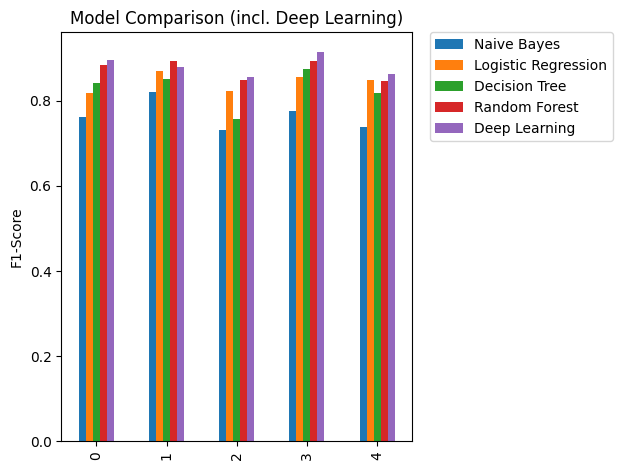

In [12]:
model_results_df = pd.DataFrame(model_results)
model_results_df.plot(kind='bar')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)
plt.title('Model Comparison (incl. Deep Learning)')
plt.ylabel('F1-Score')
plt.tight_layout()
plt.show()

In [13]:
full_summary = pd.DataFrame({
    'Mean F1-Score': model_results_df.mean(),
    'Std Deviasi (Kestabilan)': model_results_df.std(),
}).sort_values(by=['Mean F1-Score', 'Std Deviasi (Kestabilan)'], ascending=[False, True])
print('=== Peringkat Model ===')
print(full_summary)
print('-' * 30)
best_model_name = full_summary.index[0]
best_model_f1 = full_summary['Mean F1-Score'].iloc[0]
print(f'\nModel terbaik: {best_model_name} (F1 = {best_model_f1:.4f})')

=== Peringkat Model ===
                     Mean F1-Score  Std Deviasi (Kestabilan)
Deep Learning             0.881099                  0.024786
Random Forest             0.872881                  0.024053
Logistic Regression       0.842794                  0.022144
Decision Tree             0.828429                  0.044881
Naive Bayes               0.764975                  0.035758
------------------------------

Model terbaik: Deep Learning (F1 = 0.8811)


# Final Model

In [15]:
# Train final Deep Learning model on full dataset
final_model = build_mlp(X.shape[1])
final_model.fit(
    X, y,
    epochs=20, batch_size=64,
    class_weight=class_weight,
    verbose=1
)

Epoch 1/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - loss: 0.4706
Epoch 2/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 0.3955
Epoch 3/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 0.3678
Epoch 4/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 0.3460
Epoch 5/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 0.3234
Epoch 6/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.3132
Epoch 7/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.3026
Epoch 8/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 0.2889
Epoch 9/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.2826
Epoch 10/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.2748
Epoch 11/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 0.2693
Epoch 12/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.2640
Epoch 13/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.2572
Epoch 14/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.2503
Epoch 15/20
591/591 ━━━━━━━━━━━━━━

In [16]:
# Save final Deep Learning model
final_model.save(BIN_DIR / 'image_classifier.keras')
print('Saved: image_classifier.keras')

Saved: image_classifier.keras


In [17]:
probs = final_model.predict(X, verbose=0).flatten()
best_th, best_f1 = 0.0, 0.0
for th in np.arange(0.3, 0.85, 0.02):
    f1 = f1_score(y, (probs >= th).astype(int))
    if f1 > best_f1:
        best_f1, best_th = f1, th
print(f'Best threshold: {best_th:.2f} (F1={best_f1:.4f})')

Best threshold: 0.64 (F1=0.9444)


In [18]:
with open(BIN_DIR / 'image_best_threshold.json', 'w') as f:
    json.dump({'threshold': float(best_th), 'f1': float(best_f1)}, f)
print('Saved: image_best_threshold.json')

Saved: image_best_threshold.json


In [20]:
oof_probs = np.zeros(len(y))

for train_idx, val_idx in gkf.split(X, y, groups):
    fold_model = build_mlp(X.shape[1])
    fold_model.fit(X[train_idx], y[train_idx], epochs=20, batch_size=64,
                   class_weight=class_weight, verbose=0)
    oof_probs[val_idx] = fold_model.predict(X[val_idx], verbose=0).flatten()

y_pred_oof = (oof_probs >= best_th).astype(int)

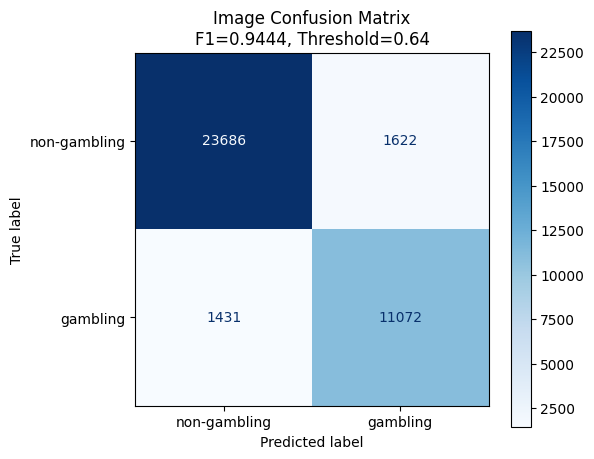


=== Classification Report ===
              precision    recall  f1-score   support

non-gambling     0.9430    0.9359    0.9395     25308
    gambling     0.8722    0.8855    0.8788     12503

    accuracy                         0.9193     37811
   macro avg     0.9076    0.9107    0.9091     37811
weighted avg     0.9196    0.9193    0.9194     37811



In [21]:
fig, ax = plt.subplots(
    figsize=(6, 5)
)

ConfusionMatrixDisplay.from_predictions(
    y,
    y_pred_oof,
    display_labels=["non-gambling", "gambling"],
    cmap="Blues",
    values_format="d",
    ax=ax,
)

ax.set_title(
    f"Image Confusion Matrix\n"
    f"F1={best_f1:.4f}, Threshold={best_th:.2f}"
)

plt.tight_layout()
plt.show()

print("\n=== Classification Report ===")
print(
    classification_report(
        y,
        y_pred_oof,
        target_names=["non-gambling", "gambling"],
        digits=4
    )
)